In [2]:
import numpy as np
import pandas as pd
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
from keras import layers
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from metrics_tracking import F1Score, plot_metrics


In [2]:
#import the datasets to test
def load_data(data_file_name):
    data = np.load(f"Preprocessed_Data/{data_file_name}")
    # Access arrays by their keys
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    X_train = X_train[..., :-1] #TEMP FIX REMOVE LATER - FIX PREPROCESSING TO GET RID OF STRING COLUMN
    X_test  = X_test[..., :-1] #TEMP FIX REMOVE LATER
    print(X_train.shape)
    print(y_train.shape)
    print(X_test.shape)
    print(y_test.shape)
    data.close()
    return X_train, y_train, X_test, y_test

data_file_name = "roads_canids_windows_200hz_3s.npz"
X_train, y_train, X_test, y_test = load_data(data_file_name)

(11280, 600, 23)
(11280,)
(13948, 600, 23)
(13948,)


In [3]:
def standardize(X_train, y_train, X_test, y_test):
    # Clip outliers 
    X_train = np.clip(X_train, -1e6, 1e6)
    X_test  = np.clip(X_test,  -1e6, 1e6)
    # Standardize features
    scaler = StandardScaler()
    X_train_flat = X_train.reshape(-1, X_train.shape[-1])
    X_test_flat  = X_test.reshape(-1,  X_test.shape[-1])
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled  = scaler.transform(X_test_flat)
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test  = X_test_scaled.reshape(X_test.shape)
    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = standardize(X_train, y_train, X_test, y_test)

In [15]:
def create_model_road(): #this is the same model we'll always use for all. 
    model = keras.Sequential()
    model.add(layers.Input(shape=(600, 23)))
    model.add(layers.Conv1D(128, 8, activation='relu'))
    model.add(layers.GlobalAveragePooling1D()) #was GlobalMaxPooling1D
    model.add(layers.Dense(1, activation='sigmoid')) #output 1 bc we only have 2 labels: attack or not attack
    return model
model = create_model_road()

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 593, 128)       │        23,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#train data 
b_size = 32
callbacks = [
    ModelCheckpoint("saved_models/best_model_road_128cnn.keras", monitor='val_auc', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8, min_lr=1e-11, verbose=1),
    EarlyStopping(monitor='val_auc', patience=15, verbose=1, restore_best_weights=True)
]
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss = 'binary_crossentropy', 
              metrics = ['accuracy', keras.metrics.AUC(name='auc'), 
              keras.metrics.Precision(name='precision'),
              keras.metrics.Recall(name='recall'),
              F1Score(name="f1")
])
history = model.fit(X_train, y_train, batch_size = b_size, epochs = 50, validation_split=0.1, callbacks = callbacks, verbose = 1)

Epoch 1/50
314/318 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9569 - auc: 0.9349 - f1: 0.3426 - loss: 0.1456 - precision: 0.6467 - recall: 0.2508
Epoch 1: val_auc improved from None to 0.85838, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9618 - auc: 0.9750 - f1: 0.5828 - loss: 0.0973 - precision: 0.7655 - recall: 0.4705 - val_accuracy: 0.7952 - val_auc: 0.8584 - val_f1: 0.7273 - val_loss: 0.5042 - val_precision: 0.8627 - val_recall: 0.6286 - learning_rate: 0.0010
Epoch 2/50
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9776 - auc: 0.9926 - f1: 0.7988 - loss: 0.0582 - precision: 0.8410 - recall: 0.7610
Epoch 2: val_auc improved from 0.85838 to 0.88585, saving model to saved_models/best_model_road_128cnn.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9785 - auc: 0.9935 - f1: 0.8029 - loss: 0.0526 - precision: 0.8377 - recall: 0.7708 - val_accuracy: 0.8475 - val_auc: 0.8859 - val_f1: 0.8147

In [18]:
def print_test_metrics(X_test, y_test, model):
    testing_acc = model.evaluate(X_test,y_test, verbose=1)
    print(f"Test loss: {testing_acc[0]}")
    print(f"Test accuracy: {testing_acc[1]}")
    print(f"Test AUC: {testing_acc[2]}")
    print(f"Test Precision: {testing_acc[3]}")
    print(f"Test Recall: {testing_acc[4]}")
    print(f"Test F1: {testing_acc[5]}")
print_test_metrics(X_test, y_test, model)

436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - auc: 0.8716 - f1: 0.6457 - loss: 0.0696 - precision: 0.9863 - recall: 0.4800              
Test loss: 0.06961239129304886
Test accuracy: 0.9886721968650818
Test AUC: 0.8716467618942261
Test Precision: 0.9863013625144958
Test Recall: 0.47999998927116394
Test F1: 0.6457398533821106


In [19]:
model_save_name = "best_ROAD_model128.keras"
model.save(f"saved_models/{model_save_name}")

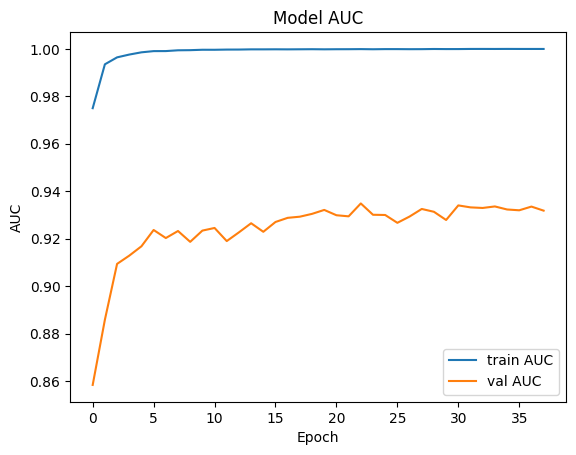

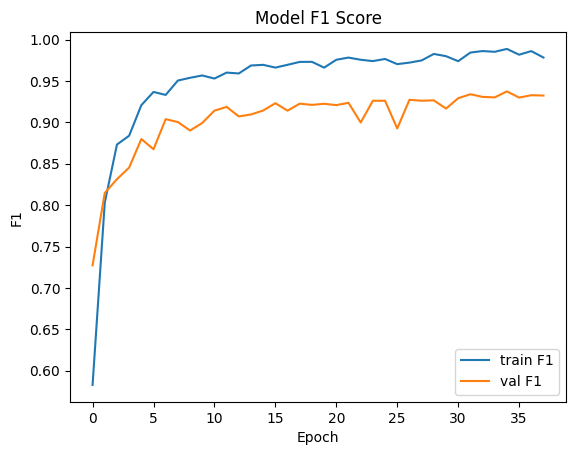

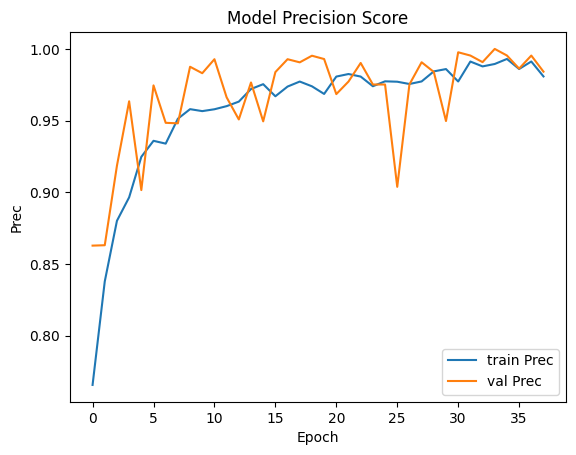

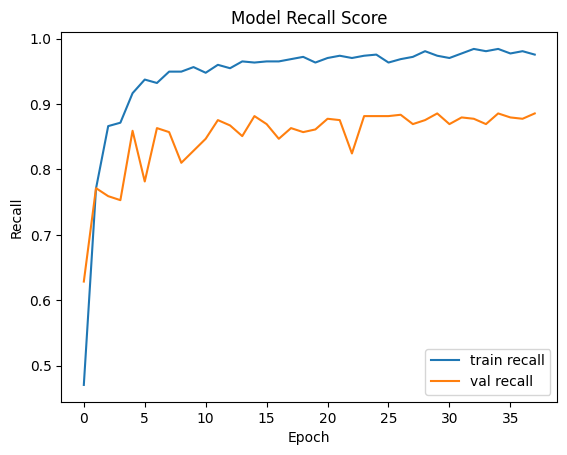

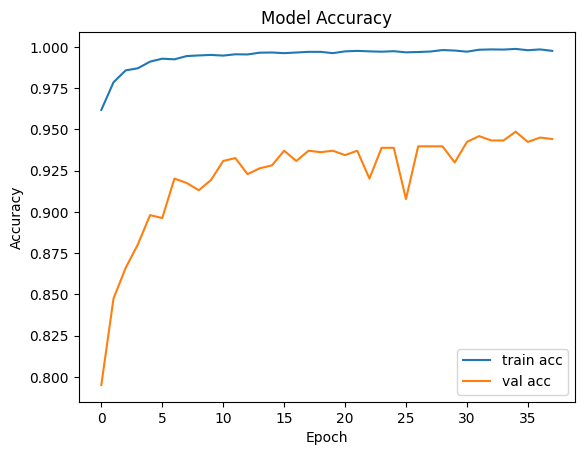

In [20]:
plot_metrics(history, model_save_name)
# plt.plot(history.history['accuracy'], label='train acc')
# plt.plot(history.history['val_accuracy'], label='val acc')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.show()

In [21]:
def print_report_and_score(model, X_test, y_test):
    y_pred_probs = model.predict(X_test).ravel()     # shape: (N,)
    y_pred = (y_pred_probs >= 0.5).astype(int)       # threshold
    print(classification_report(y_test, y_pred, target_names=["Ambient", "Attack"]))
    # --- Correct ROC-AUC for binary classifier ---
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_pred
y_pred = print_report_and_score(model, X_test, y_test)

436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
              precision    recall  f1-score   support

     Ambient       0.99      1.00      0.99     13648
      Attack       0.99      0.48      0.65       300

    accuracy                           0.99     13948
   macro avg       0.99      0.74      0.82     13948
weighted avg       0.99      0.99      0.99     13948

ROC AUC Score: 0.9940


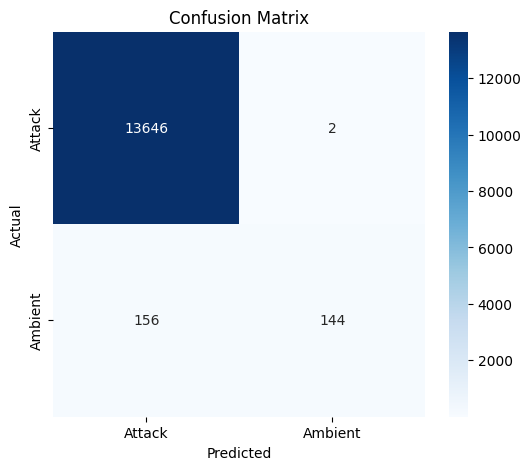

<Figure size 640x480 with 0 Axes>

In [22]:
def display_confusion_matrix(y_test, y_pred, model_name="best_ROAD_model128.keras"):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Attack", "Ambient"],
        yticklabels=["Attack", "Ambient"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    plt.savefig(f"{model_name}_confusion_matrix.png")
display_confusion_matrix(y_test, y_pred, model_save_name)

436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


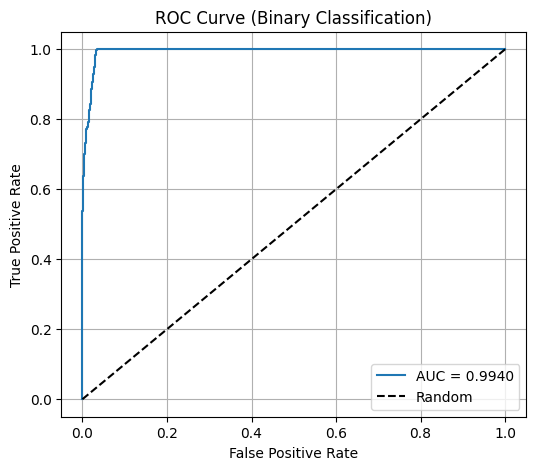

In [23]:
from sklearn.metrics import roc_curve


y_pred_proba = model.predict(X_test).ravel()   # shape (N,)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [3]:
keras_model = keras.models.load_model( #import model for quantization
    "saved_models/best_model_road_128cnn.keras",
    compile=True,
    custom_objects={"F1Score": F1Score},
    safe_mode=False
)
keras_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 593, 128)       │        23,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,429 (279.02 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,620 (186.02 KB)

In [ ]:
import tensorflow as tf
model_save_name = "best_ROAD_model128.keras"

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]#OPTIMIZE_FOR_SIZE] #OPTIMIZE.DEFAULT
tflite_model = converter.convert()
with open(model_save_name + ".tflite", "wb") as f:
    f.write(tflite_model)




INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpp48r289j\assets


INFO:tensorflow:Assets written to: C:\Users\Cyrus\AppData\Local\Temp\tmpp48r289j\assets


Saved artifact at 'C:\Users\Cyrus\AppData\Local\Temp\tmpp48r289j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 23), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1836850188112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836850189072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836850189456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836850188496: TensorSpec(shape=(), dtype=tf.resource, name=None)


NameError: name 'model_save_name' is not defined

In [ ]:
#import the datasets to test
# def load_data(data_file_name):
#     data = np.load(f"Preprocessed_Data/{data_file_name}")
#     # Access arrays by their keys
#     X_train = data["X_train"]
#     y_train = data["y_train"]
#     X_test  = data["X_test"]
#     y_test  = data["y_test"]
#     X_train = X_train[..., :-1] #TEMP FIX REMOVE LATER - FIX PREPROCESSING TO GET RID OF STRING COLUMN
#     X_test  = X_test[..., :-1] #TEMP FIX REMOVE LATER
#     print(X_train.shape)
#     print(y_train.shape)
#     print(X_test.shape)
#     print(y_test.shape)
#     data.close()
#     return X_train, y_train, X_test, y_test





ValueError: Object arrays cannot be loaded when allow_pickle=False

In [29]:

np_load_old = np.load

# modify the default parameters of np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
X_train, y_train, X_test, y_test = load_data('SynCANCleanLabeled2hrs.npz')
np.load = np_load_old

KeyError: 'X_test is not a file in the archive'